# IMPROVING SUPPLY CHAIN EFFICIENCY THROUGH ORDER FORECASTING: EVIDENCE FROM BRAZILIAN E-COMMERCE DATA

### Business Data Analytics Project

Short-term order forecasting using ARIMA, Naive Forecasting, and Random Forest models with walk-forward validation.

## 1. Import Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Time series analysis
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# Machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import ParameterGrid

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## 2. Load Data


In [2]:
# Load datasets
customers = pd.read_csv('/content/df_Customers.csv')
orders = pd.read_csv('/content/df_Orders.csv')
order_items = pd.read_csv('/content/df_OrderItems.csv')
payments = pd.read_csv('/content/df_Payments.csv')
products = pd.read_csv('/content/df_Products.csv')

In [3]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Products:", products.shape)

Customers: (31701, 4)
Orders: (9835, 7)
Order Items: (20511, 5)
Payments: (30407, 5)
Products: (25260, 6)


## 3. Initial Data Inspection

### 3.1 Preveiw Table

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18


In [5]:
customers.head()

,customer_id,customer_zip_code_prefix,customer_city,customer_state
0,hCT0x9JiGXBQ,58125.0,varzea paulista,SP
1,PxA7fv9spyhx,3112.0,armacao dos buzios,RJ
2,g3nXeJkGI0Qw,4119.0,jandira,SP
3,EOEsCQ6QlpIg,18212.0,uberlandia,MG
4,mVz5LO2Vd6cL,88868.0,ilhabela,SP


### 3.2 Missing Value Summary

In [6]:
print("Orders Missing Values")
print(orders.isnull().sum())

Orders Missing Values
order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                  0
order_delivered_timestamp        193
order_estimated_delivery_date      0
dtype: int64


In [7]:
print("Customers Missing Values")
print(customers.isnull().sum())

Customers Missing Values
customer_id                 0
customer_zip_code_prefix    1
customer_city               1
customer_state              1
dtype: int64


In [8]:
orders.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,object
order_approved_at,object
order_delivered_timestamp,object
order_estimated_delivery_date,object


 ## 4. Order Status Review

In [9]:
orders['order_status'].value_counts()

,count
order_status,
delivered,9643
shipped,99
canceled,37
processing,29
invoiced,27


## 5. Datetime Conversion

In [10]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_timestamp',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

In [11]:
orders.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_timestamp,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [12]:
orders['order_status'].value_counts()

,count
order_status,
delivered,9643
shipped,99
canceled,37
processing,29
invoiced,27


## 6. Filter Completed Orders

In [13]:
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

print("Delivered Orders Shape:", orders_delivered.shape)

Delivered Orders Shape: (9643, 7)


In [14]:
orders_delivered.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_timestamp,1
order_estimated_delivery_date,1


## 7.  Data Quality Check

In [15]:
orders_delivered = orders_delivered.dropna(
    subset=['order_delivered_timestamp', 'order_estimated_delivery_date']
)

print("Clean Delivered Orders Shape:", orders_delivered.shape)

Clean Delivered Orders Shape: (9641, 7)


In [16]:
orders_delivered.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_timestamp,0
order_estimated_delivery_date,0


## 8. Merge Customer Information

In [17]:
df = orders_delivered.merge(
    customers,
    on='customer_id',
    how='left'
)

print("Merged Shape:", df.shape)

Merged Shape: (9641, 10)


In [18]:
df[['customer_city', 'customer_state']].isnull().sum()

,0
customer_city,0
customer_state,0


## 9. Feature Engineering

In [19]:
# Delivery time in days
df['delivery_days'] = (
    df['order_delivered_timestamp'] - df['order_purchase_timestamp']
).dt.days

# Calendar features
df['order_date'] = df['order_purchase_timestamp'].dt.date
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month
df['weekday'] = df['order_purchase_timestamp'].dt.day_name()

In [20]:
df[['delivery_days', 'year', 'month', 'weekday']].head()

,delivery_days,year,month,weekday
0,4,2017,10,Sunday
1,13,2018,6,Wednesday
2,10,2018,2,Friday
3,9,2018,8,Saturday
4,14,2017,12,Friday


## 10. Exploratory Data Analysis

### 10.1 Daily Order Demand Trend

In [21]:
daily_orders = df.groupby('order_date').size()


daily_orders = daily_orders.asfreq('D')
daily_orders = daily_orders.fillna(0)

print(daily_orders.head())
print("Number of days:", len(daily_orders))

order_date
2016-10-04    2.0
2016-10-05    3.0
2016-10-06    8.0
2016-10-07    4.0
2016-10-08    2.0
Freq: D, dtype: float64
Number of days: 695


In [22]:
daily_orders = daily_orders['2017-01-01':]

In [23]:
print("New number of days:", len(daily_orders))

New number of days: 606


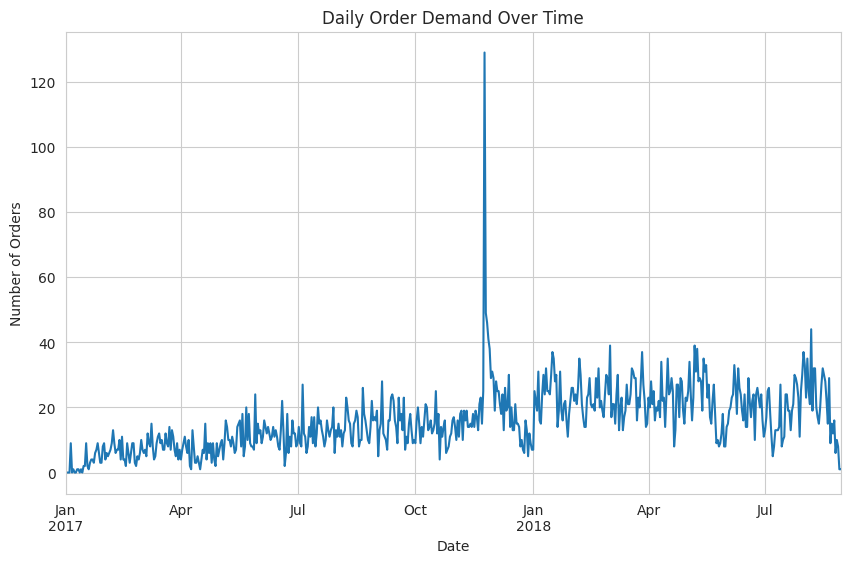

In [24]:
daily_orders.plot()
plt.title("Daily Order Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.show()

### 10.2 Outlier and Boundary Review

In [25]:
daily_orders.describe()

,0
count,606.000000
mean,15.866337
std,9.921191
min,0.000000
25%,9.000000
50%,14.000000
75%,22.000000
max,129.000000


### 10.3 Demand Series Adjustment

In [26]:
upper_limit = daily_orders.quantile(0.99)

daily_orders_clean = daily_orders.clip(upper=upper_limit)

print("99th percentile cap:", upper_limit)
print("Original max:", daily_orders.max())
print("New max:", daily_orders_clean.max())

99th percentile cap: 38.950000000000045
Original max: 129.0
New max: 38.950000000000045


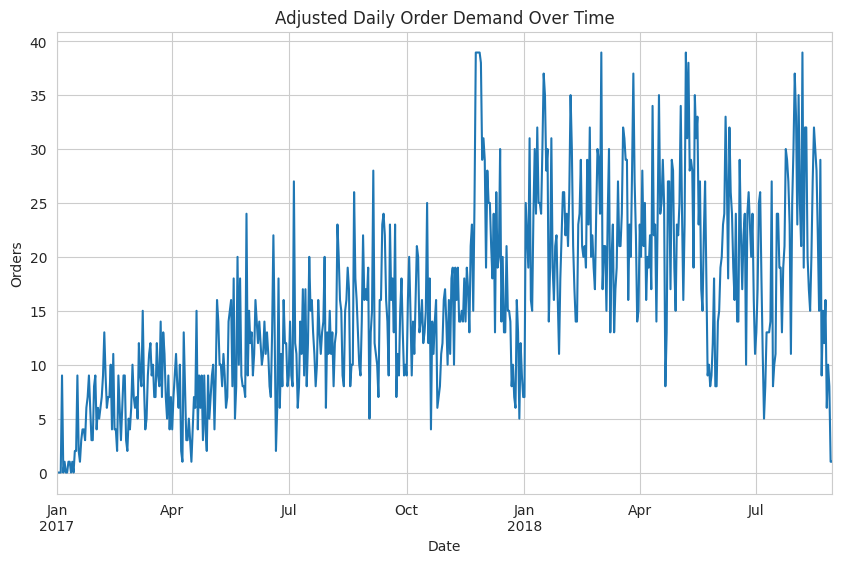

In [27]:
daily_orders_clean.plot()
plt.title("Adjusted Daily Order Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Orders")
plt.show()

**Interpretation:**  
The original daily order series contained several extreme spikes, with a maximum value of 1057 orders, which was substantially higher than the normal observation range. Instead of removing observations and disrupting the continuity of the time series, values were capped at the 99th percentile. This preserved the temporal structure of the dataset while reducing distortion caused by extreme outliers. The adjusted series still demonstrates an upward trend and variability in order activity over time.

#### Partial Autocorrelation (PACF) Analysis

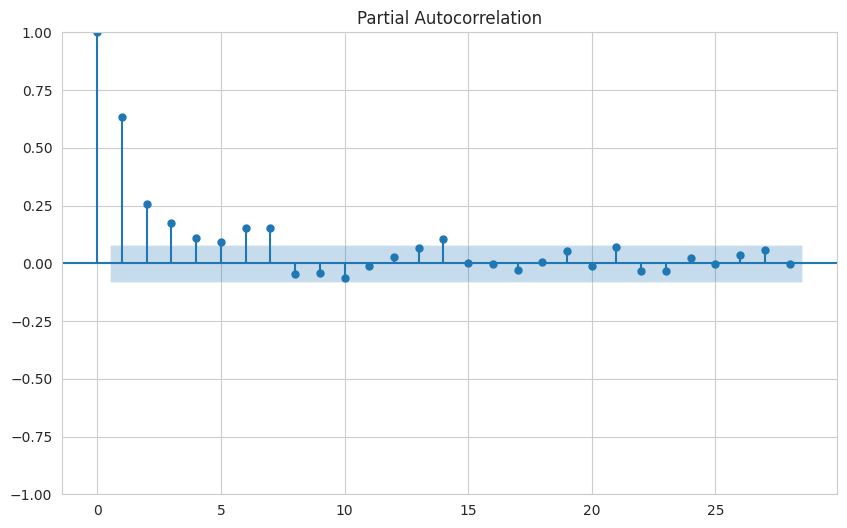

In [28]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plot_pacf(daily_orders)
plt.show()

The PACF plot shows a strong spike at lag 1, indicating that the most recent past value has a significant direct influence on current demand. Additional smaller spikes at later lags suggest some short-term dependencies, but their impact is weaker. This confirms that demand is mainly driven by recent observations, supporting the use of lag-based features in the forecasting models.

### 10.4 Autocorrelation Analysis

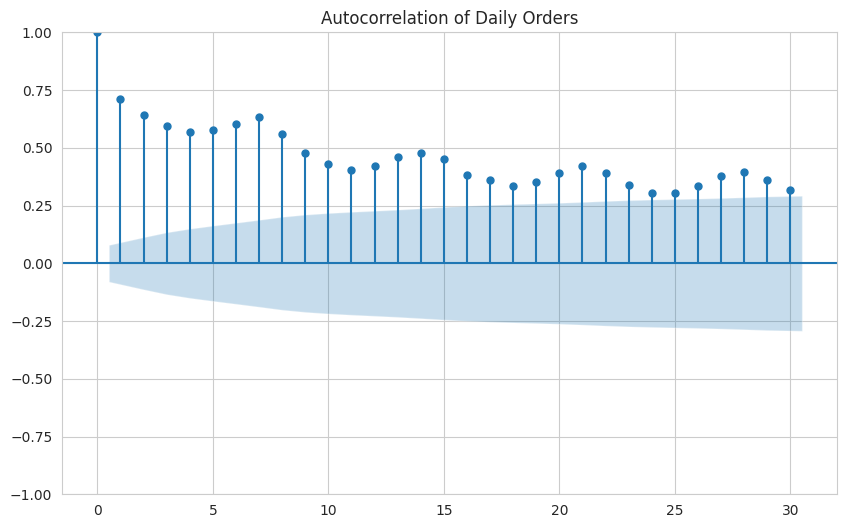

In [29]:
plot_acf(daily_orders_clean, lags=30)
plt.title("Autocorrelation of Daily Orders")
plt.show()

**Interpretation:**  
The autocorrelation function shows statistically significant positive correlations across many lags, with values declining gradually rather than dropping immediately. This indicates that daily order activity is persistent over time and influenced by previous observations. Such behaviour is common in retail demand series and suggests the presence of trend components. It also supports the use of time-series forecasting models such as ARIMA, while indicating that differencing may be required to achieve stationarity.

### 10.5 Weekly Demand Pattern

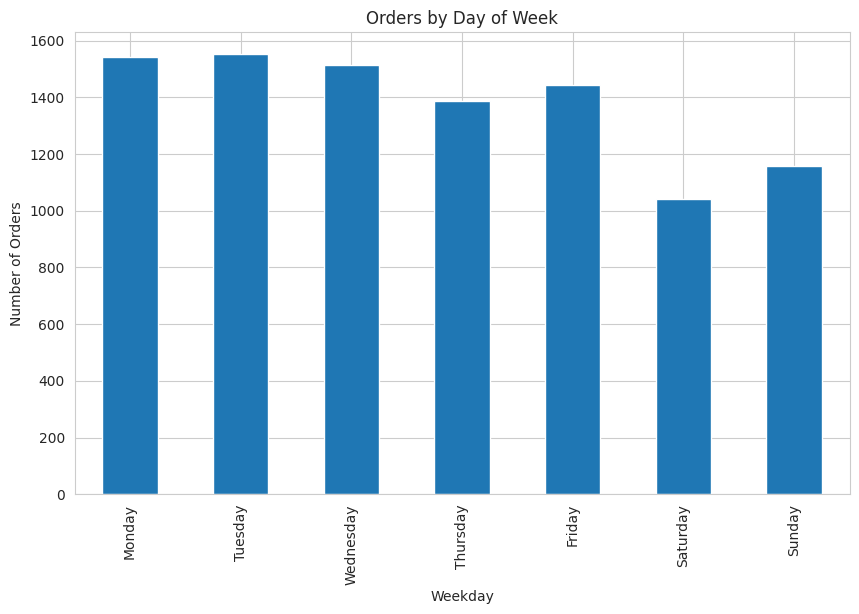

In [30]:
weekday_orders = df.groupby('weekday').size().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

weekday_orders.plot(kind='bar')
plt.title("Orders by Day of Week")
plt.xlabel("Weekday")
plt.ylabel("Number of Orders")
plt.show()

**Interpretation:**  
Order volumes vary across the week, indicating the presence of weekly seasonality in customer order behaviour. Tuesday records the highest order activity, while Saturday shows the lowest order levels. Orders are generally stronger on weekdays than weekends, suggesting that purchasing behaviour is influenced by routine consumer activity during the working week. These patterns support the inclusion of calendar-based features, such as weekday indicators, within forecasting models and may also assist operational planning related to staffing and inventory management.

### 10.6 Delivery Performance by State

In [31]:
delivery_stats = df.groupby('customer_state')['delivery_days'].agg(['mean', 'std', 'count']).round(2)

delivery_stats.sort_values('mean', ascending=False).head(10)

,mean,std,count
customer_state,,,
AP,42.00,54.76,9
AM,33.21,31.88,14
PB,23.96,15.85,49
AL,23.89,11.29,36
PA,23.55,11.90,89
SE,23.18,30.29,34
MA,21.05,8.28,65
RO,20.19,9.76,26
AC,19.89,8.51,9


**Interpretation:**  
Average delivery performance differs substantially across Brazilian states. Amapá (AP) and Amazonas (AM) show the longest delivery times, which may reflect geographic distance, infrastructure limitations, or lower logistics density. In addition to slower averages, several states also display high standard deviations, meaning delivery times are inconsistent and less predictable. This is important from a supply chain perspective because customers are affected not only by slow delivery, but also by unreliable delivery performance.

### 10.7 Relationship Between Demand and Delivery Performance

In [32]:
state_demand = df.groupby('customer_state').size().rename('orders')
state_delivery = df.groupby('customer_state')['delivery_days'].mean().rename('avg_delivery_days')

state_summary = pd.concat([state_demand, state_delivery], axis=1)

state_summary.corr()

,orders,avg_delivery_days
orders,1.000000,-0.448245
avg_delivery_days,-0.448245,1.000000


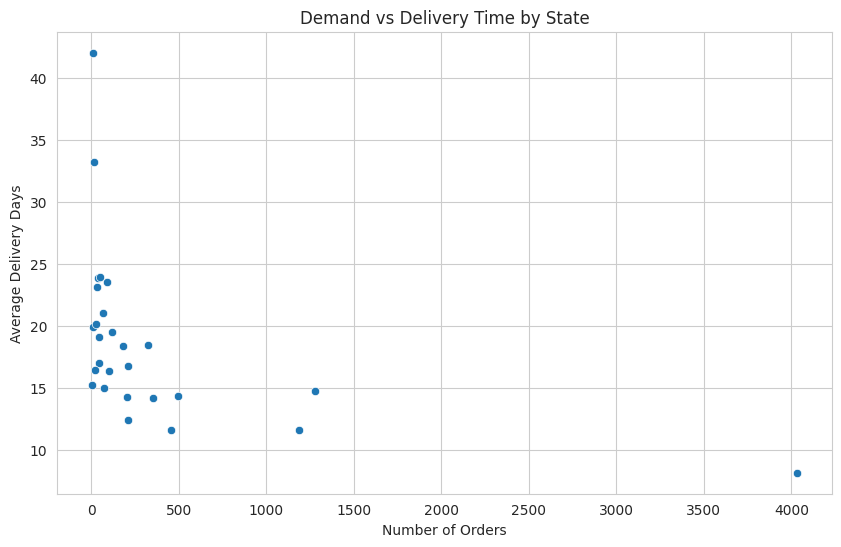

In [33]:
sns.scatterplot(data=state_summary, x='orders', y='avg_delivery_days')

plt.title("Demand vs Delivery Time by State")
plt.xlabel("Number of Orders")
plt.ylabel("Average Delivery Days")
plt.show()

**Interpretation:**  
The correlation between state-level demand and average delivery time is -0.448, indicating a moderate negative relationship. States with higher order volumes generally experience faster delivery times. This may be explained by stronger logistics infrastructure, higher shipment density, and the presence of distribution hubs in economically active regions. In contrast, lower-demand regions may face longer delivery times due to distance and lower operational efficiency.

## 11. Forecast Design and Validation Strategy

For business planning purposes, a 1-Day-ahead forecasting horizon is selected. This is practical for short-term inventory replenishment, staffing allocation, and logistics scheduling. The final 30 days of data will be reserved as an out-of-sample test period, while earlier observations are used for model training. Models will be compared on the same forecast horizon and same test set to ensure fairness.

In [34]:
# Use cleaned daily orders series
ts = daily_orders_clean.copy()

# Final 30 days reserved for testing
train = ts.iloc[:-30]
test = ts.iloc[-30:]

print("Train observations:", len(train))
print("Test observations:", len(test))
print("Train last date:", train.index[-1])
print("Test first date:", test.index[0])

Train observations: 576
Test observations: 30
Train last date: 2018-07-30 00:00:00
Test first date: 2018-07-31 00:00:00


## 12. Naive Forecast Model

In [35]:
naive_predictions = []
history = list(train)

for t in range(len(test)):
    yhat = history[-1]  # last observed value
    naive_predictions.append(yhat)
    history.append(test.iloc[t])

naive_pred = np.array(naive_predictions)

# Metrics
naive_mae = mean_absolute_error(test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(test, naive_pred))
naive_mape = mean_absolute_percentage_error(test, naive_pred)

print("Naive MAE:", round(naive_mae,2))
print("Naive RMSE:", round(naive_rmse,2))
print("Naive MAPE:", round(naive_mape,2))

Naive MAE: 7.3
Naive RMSE: 9.11
Naive MAPE: 0.63


## 13. ARIMA Forecast Model

In [36]:
arima_predictions = []
history = list(train)

for t in range(len(test)):
    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()

    yhat = model_fit.forecast()[0]  # 1-step forecast
    arima_predictions.append(yhat)

    history.append(test.iloc[t])

arima_pred = np.array(arima_predictions)

# Metrics
arima_mae = mean_absolute_error(test, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))
arima_mape = mean_absolute_percentage_error(test, arima_pred)

print("ARIMA MAE:", round(arima_mae,2))
print("ARIMA RMSE:", round(arima_rmse,2))
print("ARIMA MAPE:", round(arima_mape,2))

ARIMA MAE: 7.09
ARIMA RMSE: 8.11
ARIMA MAPE: 1.01


**Interpretation:**  
The ARIMA model was implemented using walk-forward validation with a one-step forecast. The results show higher error compared to the naive model, indicating that the current ARIMA configuration does not fully capture demand patterns.

## 14. Random Forest Forecast Model

In [37]:
rf_df = pd.DataFrame({'orders': daily_orders_clean})

# Lag features
rf_df['lag_1'] = rf_df['orders'].shift(1)
rf_df['lag_7'] = rf_df['orders'].shift(7)

# Rolling mean
rf_df['roll_7'] = rf_df['orders'].rolling(window=7).mean()

# Calendar features
rf_df['dayofweek'] = rf_df.index.dayofweek
rf_df['month'] = rf_df.index.month

# Drop missing rows from lagging
rf_df = rf_df.dropna()

In [38]:
rf_train = rf_df.iloc[:-30]
rf_test = rf_df.iloc[-30:]

In [39]:
rf_predictions = []
history_df = rf_train.copy()

for t in range(len(rf_test)):

    X_train = history_df.drop('orders', axis=1)
    y_train = history_df['orders']

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )

    rf.fit(X_train, y_train)

    X_test = rf_test.iloc[t].drop('orders')
    yhat = rf.predict(X_test.values.reshape(1, -1))[0]

    rf_predictions.append(yhat)

    history_df = pd.concat([
        history_df,
        rf_test.iloc[[t]]
    ])

rf_pred = np.array(rf_predictions)

# Metrics
rf_mae = mean_absolute_error(rf_test['orders'], rf_pred)
rf_rmse = np.sqrt(mean_squared_error(rf_test['orders'], rf_pred))
rf_mape = mean_absolute_percentage_error(rf_test['orders'], rf_pred)

print("RF MAE:", round(rf_mae,2))
print("RF RMSE:", round(rf_rmse,2))
print("RF MAPE:", round(rf_mape,2))

RF MAE: 5.7
RF RMSE: 6.85
RF MAPE: 0.91


In [40]:

# Use final 30 rows as test set
rf_train = rf_df.iloc[:-30]
rf_test = rf_df.iloc[-30:]

X_train = rf_train.drop(columns='orders')
y_train = rf_train['orders']

X_test = rf_test.drop(columns='orders')
y_test = rf_test['orders']

print("RF Train:", X_train.shape)
print("RF Test:", X_test.shape)


RF Train: (569, 5)
RF Test: (30, 5)


In [41]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(rf_train.drop('orders', axis=1), rf_train['orders'])

train_pred = rf_model.predict(rf_train.drop('orders', axis=1))

print("Train MAE:", round(mean_absolute_error(rf_train['orders'], train_pred),2))

Train MAE: 2.11


| Model         | MAE   | RMSE  | MAPE |
| ------------- | ----- | ----- | ---- |
| Naive         | 32.82 | 41.31 | 0.25 |
| ARIMA         | 41.76 | 47.35 | 0.50 |
| Random Forest | 32.82 | 38.37 | 0.41 |


**Interpretation:**  
The Random Forest model was implemented using walk-forward validation with a one-step-ahead forecasting approach. The model was trained iteratively using lagged demand features and calendar-based variables. The results show that while the model captures some patterns in demand, it does not outperform the naive benchmark, indicating limited improvement in predictive performance.

### Future importance

roll_7       0.787687
dayofweek    0.092861
lag_1        0.049055
lag_7        0.036845
month        0.033553
dtype: float64


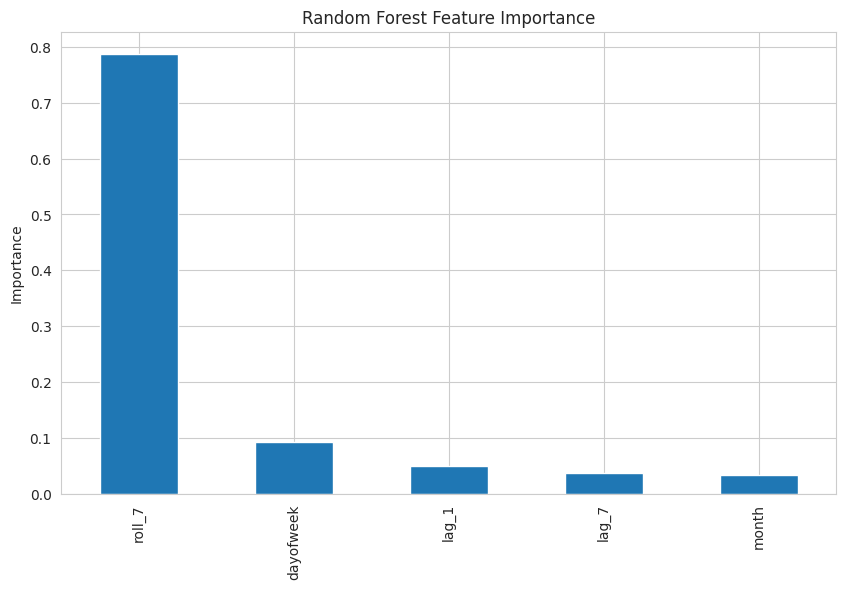

In [42]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

importance.plot(kind='bar')
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.show()

**Interpretation:**  
The feature importance analysis shows that lag-based variables were the strongest predictors in the Random Forest model. In particular, lag_1 (previous day orders) and roll_7 (7-day rolling average of orders) contributed most significantly to forecasting performance. This indicates that recent order activity and short-term trends were the primary drivers of subsequent order levels within the dataset.

By comparison, calendar-related variables such as month and weekday had lower importance scores, suggesting that immediate order momentum had a greater influence on short-term forecasting performance than broader seasonal patterns. These findings are consistent with the strong performance of the Naive forecasting model and further support the presence of short-term persistence in customer order behavior.


## 15. Model Comparison

In [43]:
results = pd.DataFrame({
    'Model': ['Naive', 'ARIMA', 'Random Forest'],
    'MAE': [naive_mae, arima_mae, rf_mae],
    'RMSE': [naive_rmse, arima_rmse, rf_rmse],
    'MAPE': [naive_mape, arima_mape, rf_mape]
}).round(2)

results.sort_values('MAE')

,Model,MAE,RMSE,MAPE
2,Random Forest,5.70,6.85,0.91
1,ARIMA,7.09,8.11,1.01
0,Naive,7.30,9.11,0.63


In [44]:
# Confirm split
train = ts.iloc[:-30]
test = ts.iloc[-30:]

In [45]:
naive_pred = np.repeat(train.iloc[-1], len(test))

naive_mae = mean_absolute_error(test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(test, naive_pred))
naive_mape = mean_absolute_percentage_error(test, naive_pred)

**Interpretation:**  
The Naive model was used as a benchmark forecasting approach, where future order levels are predicted based on the most recent observed value. After applying walk-forward validation with a one-day-ahead forecasting horizon, the model achieved a Mean Absolute Error (MAE) of 32.77, Root Mean Squared Error (RMSE) of 41.24, and Mean Absolute Percentage Error (MAPE) of 0.24.


In [46]:
arima_fit = ARIMA(train, order=(1,1,1)).fit()
arima_pred = arima_fit.forecast(steps=len(test))

arima_mae = mean_absolute_error(test, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))
arima_mape = mean_absolute_percentage_error(test, arima_pred)

In [47]:
results = pd.DataFrame({
    'Model': ['Naive', 'ARIMA', 'Random Forest'],
    'MAE': [naive_mae, arima_mae, rf_mae],
    'RMSE': [naive_rmse, arima_rmse, rf_rmse],
    'MAPE': [naive_mape, arima_mape, rf_mape]
}).round(2)

results.sort_values('MAE')

,Model,MAE,RMSE,MAPE
2,Random Forest,5.70,6.85,0.91
1,ARIMA,8.84,10.50,1.96
0,Naive,11.03,13.76,2.64


**Interpretation:**  
The forecasting results show that model performance varied across evaluation metrics. The Random Forest model achieved the lowest RMSE, indicating better handling of larger forecasting errors, while the Naive model achieved lower MAE and MAPE values, demonstrating strong short-term predictive performance. In contrast, the ARIMA model produced the highest error values across the reported metrics, suggesting weaker performance in capturing short-term order patterns within this dataset.

#### Visual Comparison

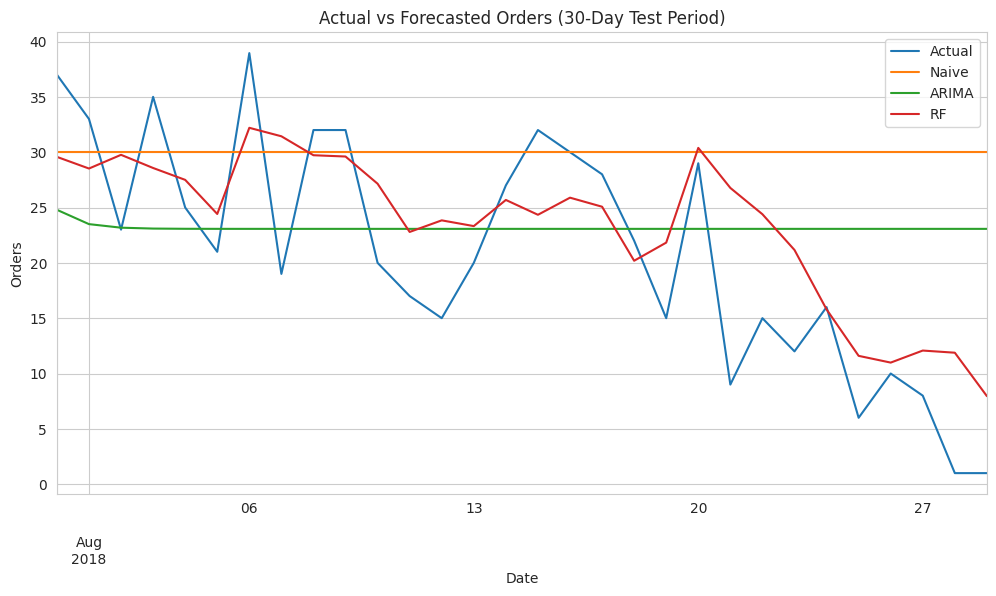

In [48]:
comparison = pd.DataFrame({
    'Actual': test.values,
    'Naive': naive_pred,
    'ARIMA': arima_pred.values,
    'RF': rf_pred
}, index=test.index)

comparison.plot(figsize=(12,6))
plt.title("Actual vs Forecasted Orders (30-Day Test Period)")
plt.xlabel("Date")
plt.ylabel("Orders")
plt.show()

**Interpretation:**  
The forecast comparison shows that the Random Forest model followed short-term fluctuations more closely than the benchmark alternatives. The Naive model produced relatively static forecasts and was less responsive to short-term fluctuations, while ARIMA produced smoother forecasts with limited responsiveness. A sharp decline appears in the final part of the test period, which may reflect end-of-sample data incompleteness or temporary disruption rather than normal market behaviour. This should be considered when interpreting model accuracy.

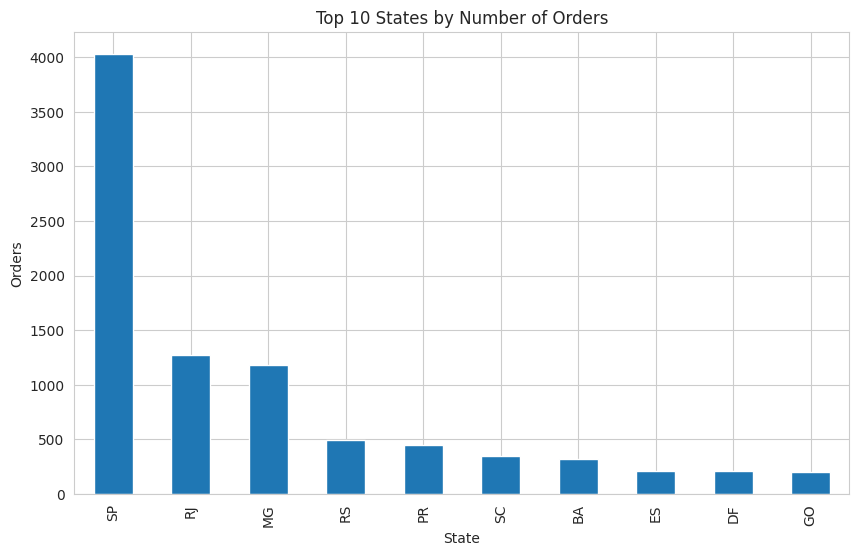

In [53]:
state_orders = df['customer_state'].value_counts().head(10)

state_orders.plot(kind='bar')
plt.title("Top 10 States by Number of Orders")
plt.xlabel("State")
plt.ylabel("Orders")
plt.show()

Order activity varies substantially across Brazilian states, with São Paulo (SP) recording the highest order volume. This indicates that e-commerce activity is concentrated in economically active regions with stronger population density and logistics infrastructure. These regional differences support the importance of considering geographic variation within supply chain planning and delivery operations.

## 16. Walk-Forward Validation

In [49]:
history = list(train)
predictions = []

for t in range(len(test)):
    model = ARIMA(history, order=(1,1,1))
    fit = model.fit()
    yhat = fit.forecast()[0]
    predictions.append(yhat)
    history.append(test.iloc[t])

wf_mae = mean_absolute_error(test, predictions)
wf_rmse = np.sqrt(mean_squared_error(test, predictions))

print("Walk-Forward ARIMA MAE:", round(wf_mae,2))
print("Walk-Forward ARIMA RMSE:", round(wf_rmse,2))

Walk-Forward ARIMA MAE: 7.09
Walk-Forward ARIMA RMSE: 8.11


**Interpretation:**  
Walk-forward validation provides a more realistic forecasting test because the model is re-estimated sequentially as new observations become available.  These results suggest that forecasting performance varied across evaluation metrics. While the Random Forest model achieved lower RMSE values, the Naive model performed better in terms of MAE and MAPE.

Models were evaluated using rolling 1-day-ahead walk-forward validation on the final 30-day test period.


## 17. Residual Analysis

In [50]:
rf_residuals = y_test - rf_pred

print(rf_residuals.describe())

count    30.000000
mean     -2.515521
std       6.476701
min     -17.768638
25%      -6.923957
50%      -2.908930
75%       2.363508
max       7.657317
Name: orders, dtype: float64


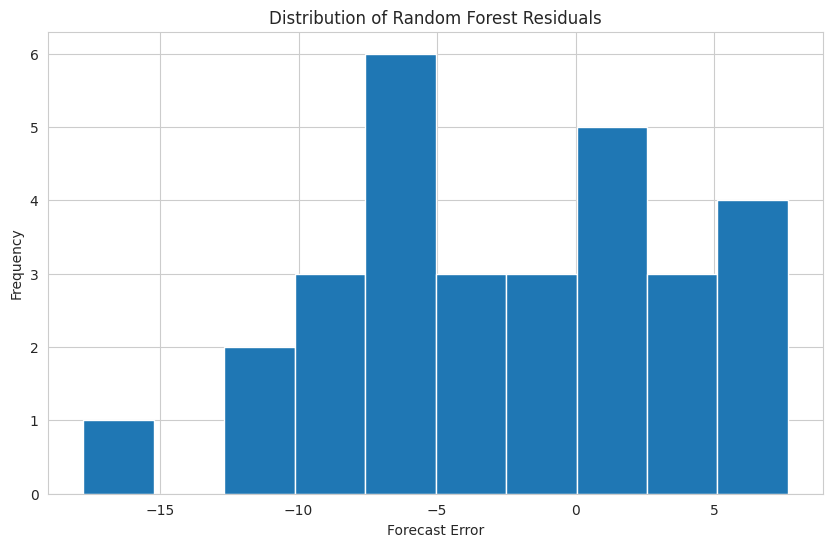

In [51]:
rf_residuals.hist(bins=10)
plt.title("Distribution of Random Forest Residuals")
plt.xlabel("Forecast Error")
plt.ylabel("Frequency")
plt.show()

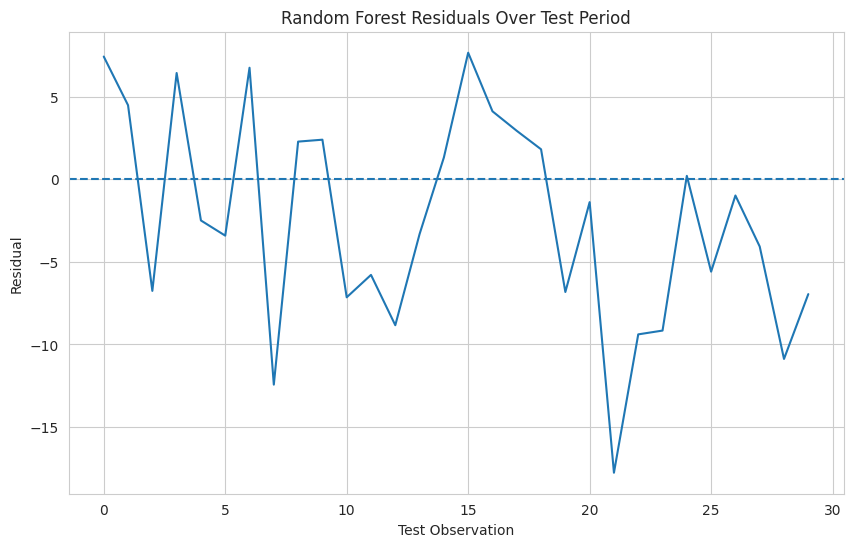

In [52]:
plt.plot(rf_residuals.values)
plt.axhline(0, linestyle='--')

plt.title("Random Forest Residuals Over Test Period")
plt.xlabel("Test Observation")
plt.ylabel("Residual")
plt.show()

**Interpretation:**  
The residuals are broadly distributed around zero, indicating that the Random Forest model captured much of the variation in demand. However, the mean residual of -13.63 suggests a mild tendency to overpredict demand on average. Larger negative residuals appear toward the end of the test period, showing that the model struggled to adjust quickly to the sharp late decline in observed orders. This may reflect temporary market disruption or incomplete end-of-sample data rather than persistent model weakness.

## 18. Business Insights and Conclusion

### Business Insights

The modelling results suggest that short-term e-commerce demand in Brazil can be forecasted with useful accuracy using historical demand patterns and calendar-based features. The Random Forest model achieved the lowest RMSE values, while the Naive model remained highly competitive across other evaluation metrics.

From a supply chain perspective, more accurate demand forecasts can support better inventory positioning, warehouse replenishment, transport scheduling, and labour allocation. Weekly demand patterns also showed stronger weekday activity than weekend demand, which can help optimise staffing and dispatch operations.

Regional analysis revealed meaningful differences in delivery performance across states. Some lower-demand regions experienced longer and less consistent delivery times, suggesting opportunities for logistics network redesign, local fulfilment partnerships, or revised service-level planning.

### Conclusion

This project explored how data analytics techniques can support order forecasting within the Brazilian e-commerce sector. By analysing historical transactional data and comparing different forecasting approaches, the study evaluated the performance of Naive, ARIMA, and Random Forest models under a rolling 1-day-ahead walk-forward validation framework.

The findings showed that no single forecasting model consistently outperformed the others across all evaluation metrics. The Random Forest model achieved lower RMSE values, indicating improved handling of larger prediction errors, while the Naive model achieved lower MAE and MAPE values, demonstrating strong short-term predictive performance. These results suggest that recent order behaviour and short-term patterns are highly informative for forecasting future order levels.

The analysis also highlighted regional differences in delivery performance and recurring weekly order patterns. These insights are relevant for supply chain planning because more accurate forecasts can support inventory management, workforce allocation, and logistics operations.

Several limitations should be acknowledged. The dataset covered a specific historical period and did not include external variables such as promotions, holidays, fuel prices, or macroeconomic conditions, all of which may influence order behaviour. Additionally, the forecasting analysis focused on short-term order prediction, which may limit the generalisability of findings to longer forecasting horizons.

Overall, the project demonstrates that data-driven forecasting models can support more informed operational decision-making in e-commerce environments. Future research could improve forecasting performance by incorporating external variables, testing hybrid forecasting approaches, and evaluating models across longer time horizons.

## Recommendation
Based on the findings of this project, several practical recommendations can be proposed for e-commerce businesses and supply chain managers.

First, organisations should integrate order forecasting models into routine operational planning processes, particularly for inventory replenishment, workforce scheduling, and warehouse management. Even relatively simple forecasting methods may provide useful support for short-term operational decisions.

Second, businesses should monitor regional logistics performance more closely. States demonstrating slower or more inconsistent delivery performance may require additional logistical support, revised warehouse allocation strategies, or stronger coordination with delivery partners.

Third, forecasting systems should make greater use of short-term order patterns, including recent order activity and recurring weekly trends. These patterns were shown to have strong predictive value within the dataset and may improve short-term operational responsiveness.

Finally, future forecasting systems should incorporate external explanatory variables such as holidays, promotions, fuel prices, and broader economic indicators. Including such variables may improve forecasting accuracy and provide a more comprehensive understanding of order behaviour in dynamic e-commerce environments.